## SETUP


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt



def load_data(path):

    return pd.read_csv(path)



### Load result to data frame


In [131]:
single = load_data('single/result.csv')

multi = load_data('multi/result.csv')

# RAW CSR — All Entries


#### Overall CSR


In [132]:
def csr_pct(df):

    return (df['csr_pass'] == 'True').mean() * 100



data = {'Single': csr_pct(single), 'Multi': csr_pct(multi)}

overall = pd.DataFrame.from_dict(data, orient='index', columns=['CSR (%)']).round(2)

overall['Compiled'] = [(single['csr_pass'] == 'True').sum(), (multi['csr_pass'] == 'True').sum()]

overall['Total'] = [len(single), len(multi)]

print(overall)



        CSR (%)  Compiled  Total
Single    64.87       181    279
Multi     59.14       165    279


#### Per-Intent CSR


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       56.7   63.3
DECOMPOSE_CONDITIONAL         77.6   53.1
EXTRACT_CONSTANT              70.0   60.0
EXTRACT_METHOD                78.6   61.9
EXTRACT_VARIABLE              83.3  100.0
FLATTEN_CONDITIONAL           80.0   53.3
INLINE_METHOD                 28.6   76.2
INLINE_VARIABLE               81.2   62.5
REMOVE_CONTROL_FLAG           50.0   62.5
RENAME_SYMBOL                 70.7   63.4
REPLACE_LOOP_WITH_PIPELINE     0.0    0.0
SPLIT_LOOP                    68.0   68.0


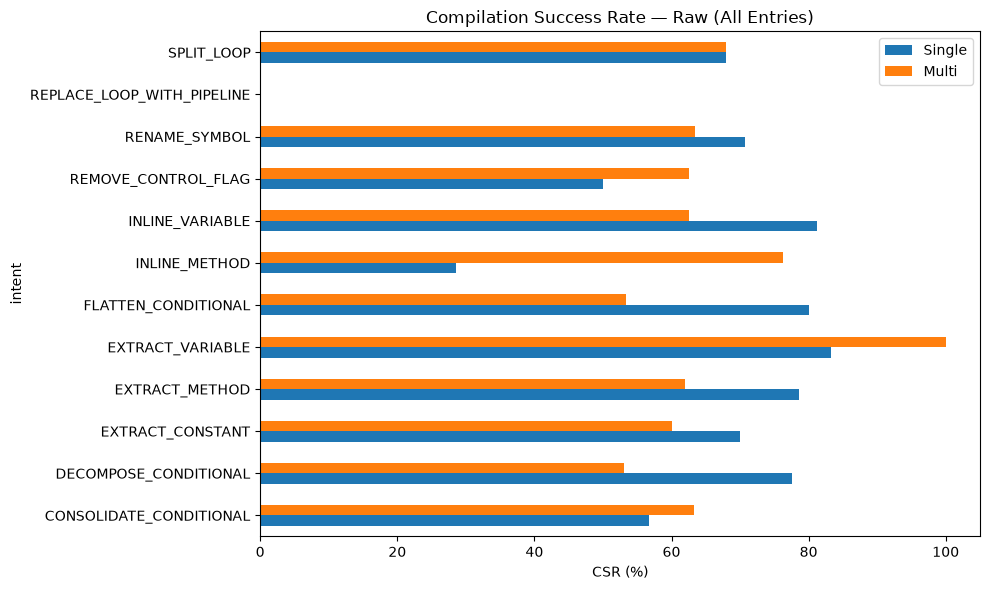

In [133]:
def intent_csr(df):

    return (df[df['csr_pass'] == 'True'].groupby('intent').size()

            / df.groupby('intent').size() * 100).round(1).fillna(0)



csr_intent = pd.DataFrame({'Single': intent_csr(single), 'Multi': intent_csr(multi)})

print(csr_intent)



ax = csr_intent.plot.barh(figsize=(10, 6))

ax.set_title('Compilation Success Rate — Raw (All Entries)')

ax.set_xlabel('CSR (%)')

plt.tight_layout()

plt.show()



#### CSR by Difficulty


In [134]:
def diff_csr(df):

    return df.groupby('difficulty')['csr_pass'].apply(

        lambda x: (x == 'True').mean() * 100

    ).round(2).fillna(0)



csr_diff = pd.DataFrame({'Single': diff_csr(single), 'Multi': diff_csr(multi)})

print(csr_diff)



            Single  Multi
difficulty               
Easy         73.53  60.29
Hard         60.00  50.91
Medium       62.82  61.54


# CSR — SUCCESS Exit Only


#### Overall CSR (SUCCESS Only)


In [135]:
s_valid = single[single['exit_status'] == 'SUCCESS']

m_valid = multi[multi['exit_status'] == 'SUCCESS']



s_pass = (s_valid['csr_pass'] == 'True').sum()

s_tot = len(s_valid)

m_pass = (m_valid['csr_pass'] == 'True').sum()

m_tot = len(m_valid)



print(f"Single: {s_pass}/{s_tot} = {s_pass/s_tot*100:.1f}%")

print(f"Multi:  {m_pass}/{m_tot} = {m_pass/m_tot*100:.1f}%")



Single: 181/272 = 66.5%
Multi:  113/198 = 57.1%


#### Per-Intent CSR (SUCCESS Only)


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       63.0   80.0
DECOMPOSE_CONDITIONAL         77.6   56.8
EXTRACT_CONSTANT              77.8   62.5
EXTRACT_METHOD                78.6   61.9
EXTRACT_VARIABLE             100.0  100.0
FLATTEN_CONDITIONAL           80.0   60.0
INLINE_METHOD                 28.6   83.3
INLINE_VARIABLE               92.9   62.5
REMOVE_CONTROL_FLAG           50.0   50.0
RENAME_SYMBOL                 70.7   63.9
REPLACE_LOOP_WITH_PIPELINE     0.0    0.0
SPLIT_LOOP                    68.0   33.3


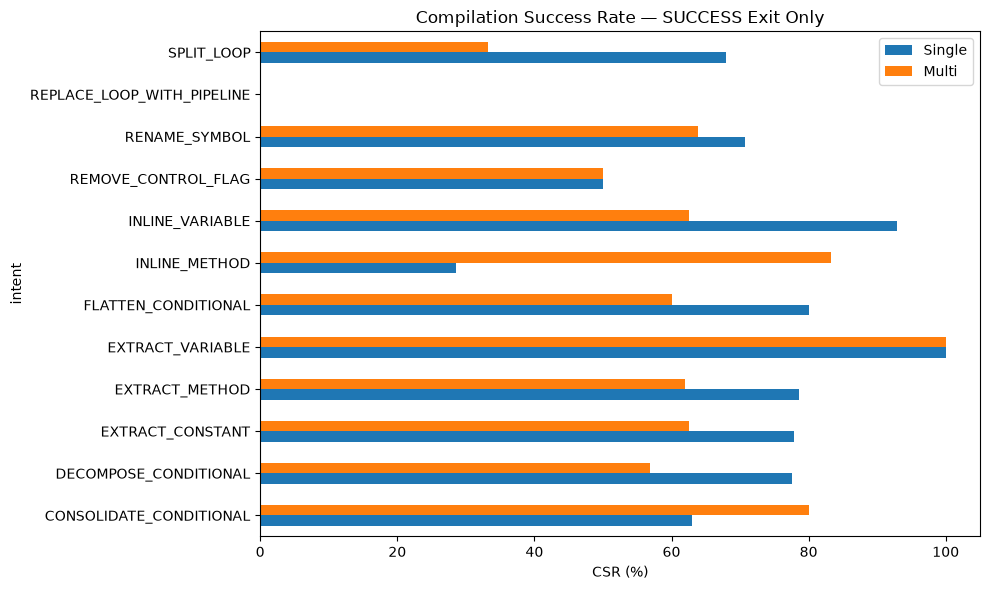

In [137]:
s_valid = single[single['exit_status'] == 'SUCCESS']

m_valid = multi[multi['exit_status'] == 'SUCCESS']



def intent_csr_success(df):

    return (df[df['csr_pass'] == 'True'].groupby('intent').size()

            / df.groupby('intent').size() * 100).round(1).fillna(0)



csr_succ = pd.DataFrame({

    'Single': intent_csr_success(s_valid),

    'Multi': intent_csr_success(m_valid),

})

print(csr_succ)



ax = csr_succ.plot.barh(figsize=(10, 6))

ax.set_title('Compilation Success Rate — SUCCESS Exit Only')

ax.set_xlabel('CSR (%)')

plt.tight_layout()

plt.show()



#### CSR by Difficulty (SUCCESS Only)


In [138]:
s_valid = single[single['exit_status'] == 'SUCCESS']

m_valid = multi[multi['exit_status'] == 'SUCCESS']



def diff_csr(df):

    return df.groupby('difficulty')['csr_pass'].apply(

        lambda x: (x == 'True').mean() * 100

    ).round(2).fillna(0)



csr_diff_succ = pd.DataFrame({

    'Single': diff_csr(s_valid),

    'Multi': diff_csr(m_valid),

})

print(csr_diff_succ)



            Single  Multi
difficulty               
Easy         74.63  61.11
Hard         63.46  55.00
Medium       64.05  55.77
